Loading libraries and Data

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [110]:
data = pd.read_csv('data.csv')
data1 =pd.read_csv('data.csv')



In [111]:
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


Cleaning Data

In [112]:
data.drop(columns=['country','date','statezip','street'],inplace = True)


In [113]:

data['age']=2026-data['yr_built']

In [114]:
data.drop(columns='yr_built',inplace=True)

In [115]:
data.drop(columns=['sqft_above','sqft_basement'],inplace=True)


In [116]:
data.drop(columns=['city','yr_renovated'],inplace=True)

In [117]:
data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,age
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,71
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,105
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,60
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,63
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,50
...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,72
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,43
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,17
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,52


Dropped columns = date,street,country,city,yearbuilt,yearrenovated,statezip


In [118]:
X=data[['bedrooms','bathrooms','sqft_living'	,'sqft_lot',	'floors',	'waterfront',	'view'	,'condition'	,'age']].values
y =data['price'].values

Feature scaling 

In [119]:
mu = np.mean(X,axis=0)
std = np.std(X,axis=0)

In [120]:
X =( X-mu)/std

In [121]:
X

array([[-0.44112227, -0.84320364, -0.82997105, ..., -0.30919434,
        -0.6671122 ,  0.53101376],
       [ 1.75970468,  0.43280154,  1.56852826, ...,  4.83007931,
         2.28641631,  1.67469295],
       [-0.44112227, -0.20520105, -0.21736733, ..., -0.30919434,
         0.80965205,  0.1609999 ],
       ...,
       [-0.44112227,  0.43280154,  0.90400897, ..., -0.30919434,
        -0.6671122 , -1.2854179 ],
       [ 0.6592912 , -0.20520105, -0.05123751, ..., -0.30919434,
        -0.6671122 , -0.10810108],
       [-0.44112227,  0.43280154, -0.67422434, ..., -0.30919434,
         0.80965205, -0.64630305]], shape=(4600, 9))

Logic

In [122]:
def predict(x,w,b):
    p = np.dot(x,w)+b
    return p

In [123]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        error = (predict(X[i],w,b)-y[i])
        error **=2
        cost +=error
    cost/=(2*m)
    return cost


        

In [124]:
def compute_gradient(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros(n)
    dj_db =0

    for i in range(m):
        error = (predict(X[i],w,b)-y[i])
        for j in range(n):
            dj_dw[j]+=error*X[i][j]
        dj_db +=error
    dj_dw/=m
    dj_db/=m

    return dj_dw,dj_db



In [125]:
def compute_descent(X,y,w,b,alpha,num_iterations):
    J_history =[]
    iterations=[]
 
    w1= w.copy()
    b1 = b
    for i in range(num_iterations):
        dj_dw,dj_db = compute_gradient(X,y,w1,b1)
        w1 = w1 -alpha*dj_dw
        b1 = b1 -alpha*dj_db
        if i%100==0 :
            J_history.append(compute_cost(X,y,w1,b1))
            iterations.append(i)
        
    return w1,b1,J_history,iterations


        
        

   

        
        

Implementation

In [126]:
w = np.zeros(X.shape[1])
b = 0
alpha = 0.01


In [127]:
w_final,b_final,J_history,iterations = compute_descent(X,y,w,b,alpha,1000)

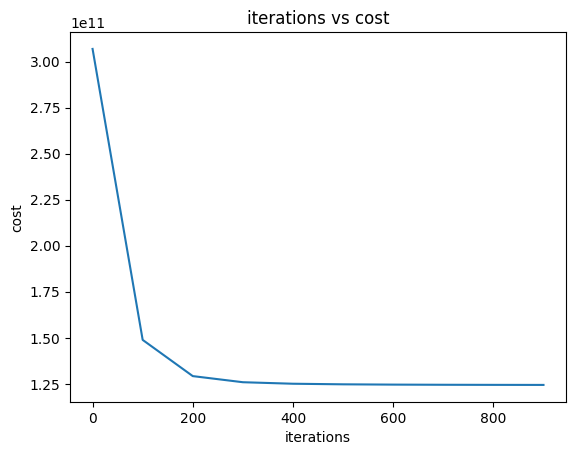

In [132]:

plt.title("iterations vs cost")
plt.xlabel("iterations")
plt.ylabel("cost")
plt.plot(iterations,J_history)




Prediction for a given input features

In [129]:
def prediction_price(w,b,features):
    y_hat = np.dot(w,features) +b
    return y_hat

In [130]:
#let the input features be 'bedrooms','bathrooms','sqft_living'	,'sqft_lot',	'floors',	'waterfront',	'view'	,'condition'	,'age'
input_features = [5,3,200,100,4,1,0,0,150]
input_features = (input_features-mu)/std
predicted_price = prediction_price(w_final,b_final,input_features)
print(f"predicted price for the given input features is : {predicted_price}")

predicted price for the given input features is : 664267.7425588765


In [131]:
print(w_final)


[-49616.76106544  51771.87387866 232646.71720099 -21861.23596659
  25745.41729232  30203.92872999  35753.56314007  17689.13202883
  72317.65280785]


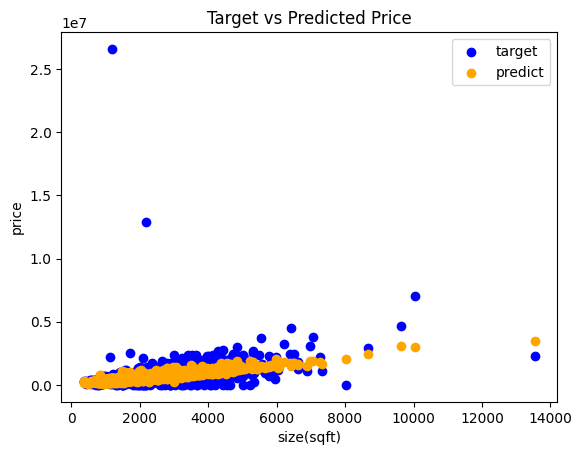

In [140]:
y_pred = np.dot(X, w_final) + b_final

sqft_living = data['sqft_living']

plt.scatter(sqft_living, y, color='blue', label='target')
plt.scatter(sqft_living, y_pred, color='orange', label='predict')

plt.xlabel("size(sqft)")
plt.ylabel("price")
plt.title("Target vs Predicted Price")
plt.legend()
plt.show()